# 4D test: an annealed Boltzmann generator for two repelling charges

We sample from a 4-dimensional energy-based target via a *Boltzmann generator* — a normalizing flow trained against a sequence of bridge potentials that anneal from a tractable source to the physical target. This is the smallest non-trivial example that exhibits the hallmarks of real molecular Boltzmann-generator workloads: a continuous symmetry the flow has to discover, a hard repulsive barrier, and a particle-exchange symmetry.

- **Source.** $\mu_0 = \mathcal N(0, I_4)$, with potential $U_0(x) = \tfrac{1}{2}|x|^2$.
- **Target.** Two unit charges in $\mathbb R^2$, each soft-confined to a ring of radius $r_0=2$, with a regularized 3D Coulomb interaction:
$$
U_1(x_1, x_2) \;=\; a\bigl[\,(|x_1|^2 - r_0^2)^2 + (|x_2|^2 - r_0^2)^2\,\bigr] \;+\; \frac{q^2}{\sqrt{|x_1 - x_2|^2 + \varepsilon^2}}, \qquad x = (x_1, x_2) \in \mathbb R^4,
$$
with $a=1$, $q^2=4$, $r_0=2$, $\varepsilon=10^{-3}$. The regularization keeps gradients finite at $x_1 = x_2$ while letting the target behave like a true Coulomb away from collisions.
- **Symmetries.** $U_1$ is invariant under (i) rigid 2D rotations of $(x_1, x_2)$ and (ii) particle exchange $(x_1, x_2) \leftrightarrow (x_2, x_1)$. The flow has to learn both from data, since `NSF` on Cartesian $[a,b]^4$ has neither built in.
- **Why anneal.** Training reverse-KL directly from $\mu_0$ to $\mu_1$ is an out-of-distribution problem at initialization (the Gaussian and the repulsive ring barely overlap), so importance weights collapse and the flow gets stuck. The annealing schedule $U_k = (1 - c_k) U_0 + c_k U_1$ with $c_k = k/M$ keeps each consecutive pair $(\mu_{k-1}, \mu_k)$ close enough that incremental training works.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent)) # add project root to search path

import os
os.environ.setdefault("TRITON_PRINT_AUTOTUNING", "0")
os.environ.setdefault("TORCHINDUCTOR_COMPILE_THREADS", "1")

import math
import torch
from zflows import (
    Potential, Gaussian, NSF, Linear_Combination,
    reverse_KL, compute_ESS_log, resample, rejuvenation,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Source and target potentials

Both potentials are `Potential` subclasses returning $U(x)$ for a batch of points. The Coulomb term is the only piece that needs the regularizer; everything else is closed-form polynomial.

In [2]:
# source: standard 4D Gaussian
u_source = Gaussian(mean=[0.0] * 4, variance=[1.0] * 4).to(device)

# target: two charges on a soft annulus, repelling via regularized 3D Coulomb
class U_target(Potential):
    def __init__(self, r0=2.0, a=1.0, q2=4.0, eps=1e-3):
        super().__init__()
        self.r0, self.a, self.q2, self.eps = r0, a, q2, eps
    def forward(self, x):
        x1, x2 = x[:, :2], x[:, 2:]
        sq1 = (x1 ** 2).sum(-1); sq2 = (x2 ** 2).sum(-1)
        conf = self.a * ((sq1 - self.r0 ** 2) ** 2 + (sq2 - self.r0 ** 2) ** 2)
        d2   = ((x1 - x2) ** 2).sum(-1)
        coul = self.q2 / (d2 + self.eps ** 2).sqrt()
        return conf + coul

u_target = U_target().to(device)

## The annealing pipeline

We build a ladder of $M+1$ rungs $c_0 = 0, c_1 = 1/M, \dots, c_M = 1$ and a sequence of bridge potentials
$$
U_k(x) = (1 - c_k)\,U_0(x) + c_k\,U_1(x), \qquad k = 0, 1, \dots, M,
$$
with $\mu_k \propto \exp(-U_k)$. Each rung's training step does five things, in order:

1. **Resample.** Draw a working set $x_{\mathrm{train}, k-1}$ of size $N_{\mathrm{train}}$ uniformly with replacement from the previous rung's particle cloud $x_{\mathrm{valid}, k-1} \sim \mu_{k-1}$.
2. **Train.** Update the *single* shared flow $F$ to minimize reverse-KL from $\mu_{k-1}$ to $\mu_k$, treating $x_{\mathrm{train}, k-1}$ as samples from the source. The $U_{k-1}(x)$ term is parameter-independent and drops out of the gradient, so `reverse_KL(x, target=U_k, flow=F)` is the correct loss as-is.
3. **Importance sample.** Push the full validation set $x_{\mathrm{valid}, k-1}$ through $F$ to get proposals $y$ and log-weights $\log w = -U_k(y) + U_{k-1}(x_{\mathrm{valid}, k-1}) + \log|\det J_F|$. Report the ESS as a self-test for this rung.
4. **Resample by weight.** Multinomial draw to convert the weighted cloud into an equally-weighted cloud $\tilde y$.
5. **Rejuvenate.** Run MALA (Metropolis-adjusted Langevin) against $U_k$ to break duplicate particles and remove residual proposal bias. Output $x_{\mathrm{valid}, k}$ for the next rung.

Only the validation cloud $x_{\mathrm{valid}, k}$ is carried across rungs; the optimizer state is re-used so the flow warm-starts each step.

The full implementation lives in [`tests/4D_Boltzmann_generator.py`](4D_Boltzmann_generator.py). The notebook below loads its cached output and runs the analysis.

In [3]:
PT_PATH = pathlib.Path.cwd() / "4D_Boltzmann_generator.pt"
assert PT_PATH.exists(), (
    f"{PT_PATH} not found — run `python -m tests.4D_Boltzmann_generator` first "
    "to populate it. Training takes a few minutes on a single GPU."
)

saved = torch.load(PT_PATH, weights_only=False)
x_valid_history = saved["x_valid_history"] # list of CPU tensors, indexed 0..M
ess_history     = saved["ess_history"]     # list of M floats, one per rung
M_total = len(x_valid_history) - 1
print(f"M = {M_total}, N_valid = {x_valid_history[0].shape[0]}")

M = 12, N_valid = 120000


## ESS along the ladder

At every rung we measure the Effective Sample Size of the flow's proposal,
$$
\mathrm{ESS}_k \;=\; \frac{\bigl(\sum_i w_i^{(k)}\bigr)^2}{N_{\mathrm{valid}}\,\sum_i \bigl(w_i^{(k)}\bigr)^2}, \qquad \log w^{(k)} = -U_k\!\bigl(F(x)\bigr) + U_{k-1}(x) + \log|\det J_F(x)|.
$$
This is the first-order diagnostic of how well $F$ moves $\mu_{k-1}$ to $\mu_k$. A pipeline that worked well at every rung gives $\mathrm{ESS}_k$ uniformly in the $0.4{-}0.9$ range. Catastrophic mode-mismatch (e.g. trying to jump from $\mu_0$ straight to $\mu_M$) collapses $\mathrm{ESS}$ to $\sim 0$, which is exactly what annealing is designed to avoid.

In [4]:
print("ESS history (per anneal step):")
for k, e in enumerate(ess_history, start=1):
    print(f"  step {k:>2}: ESS = {e:.4f}")

ESS history (per anneal step):
  step  1: ESS = 0.7371
  step  2: ESS = 0.8871
  step  3: ESS = 0.9613
  step  4: ESS = 0.9706
  step  5: ESS = 0.9740
  step  6: ESS = 0.9697
  step  7: ESS = 0.9674
  step  8: ESS = 0.9766
  step  9: ESS = 0.9768
  step 10: ESS = 0.9761
  step 11: ESS = 0.9783
  step 12: ESS = 0.9754


## Visualizing the annealed cloud

We plot the validation particles at $k = 0, 4, 8, 12$ in two rows.

- **Row 1 (Cartesian).** Both particles' $(x, y)$ positions are scattered, in different colours. The Gaussian blob at $k=0$ should collapse onto a ring of radius $r_0 = 2$ as $k$ grows — that's the *marginal* signature of confinement.
- **Row 2 (S$^1$ polar histogram).** The relative angle $\Delta\theta = \theta_2 - \theta_1 \in (-\pi, \pi]$, with $\theta_i = \mathrm{atan2}(y_i, x_i)$. This is the *joint* signal that the rotational symmetry of row 1 hides:
  - At $k=0$, particles are independent and $\Delta\theta$ is uniform on the circle. Equivalently, $\lvert\Delta\theta\rvert$ has mean $\pi/2 \approx 90^\circ$.
  - As $c_k \to 1$, Coulomb repulsion drives the particles antipodal, so $\Delta\theta$ concentrates near $\pm \pi \approx 180^\circ$ (a tall bar at the *left* of the polar plot).

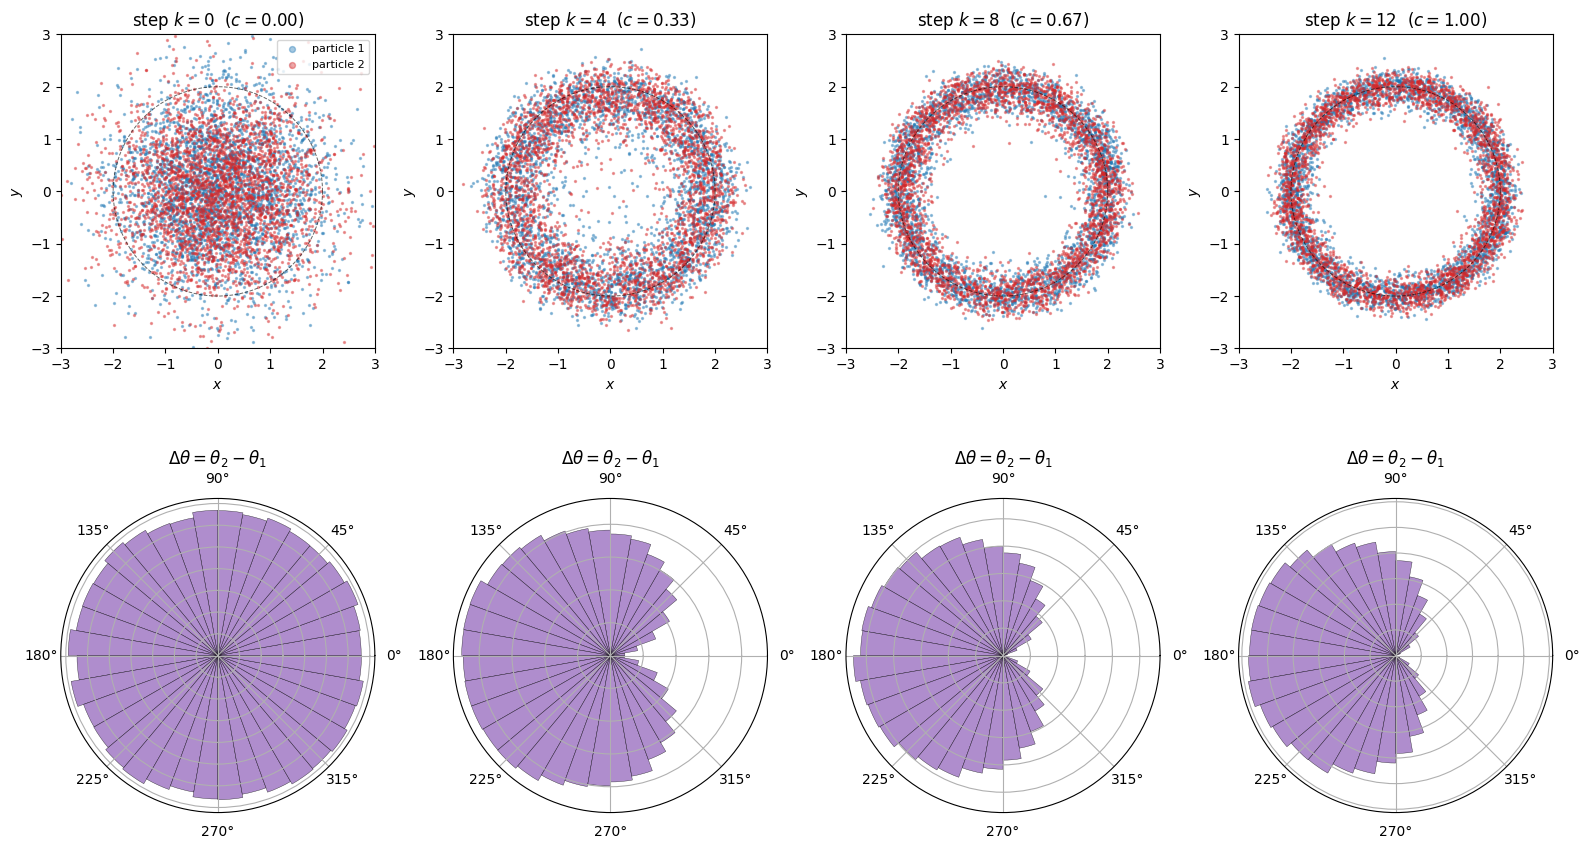

In [5]:
import matplotlib.pyplot as plt

steps_to_plot = [0, 4, 8, 12]
N_PLOT  = 3000
N_BINS  = 36

theta_grid = torch.linspace(0, 2 * math.pi, 200)
ring_x = (2.0 * torch.cos(theta_grid)).numpy()
ring_y = (2.0 * torch.sin(theta_grid)).numpy()

fig = plt.figure(figsize=(4 * len(steps_to_plot), 9))
for col, k in enumerate(steps_to_plot):
    x_k = x_valid_history[k]
    c_k = k / M_total

    # row 1: Cartesian scatter of both particles
    ax = fig.add_subplot(2, len(steps_to_plot), col + 1)
    idx = torch.randperm(x_k.shape[0])[:N_PLOT]
    pts = x_k[idx].numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4, color="tab:blue", label="particle 1")
    ax.scatter(pts[:, 2], pts[:, 3], s=2, alpha=0.4, color="tab:red",  label="particle 2")
    ax.plot(ring_x, ring_y, color="black", lw=0.7, ls="--", alpha=0.6)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    ax.set_title(f"step $k={k}$  ($c={c_k:.2f}$)")
    if col == 0:
        ax.legend(loc="upper right", fontsize=8, markerscale=3)

    # row 2: polar histogram of Δθ on S^1
    ax_p = fig.add_subplot(2, len(steps_to_plot), len(steps_to_plot) + col + 1, projection="polar")
    theta1 = torch.atan2(x_k[:, 1], x_k[:, 0])
    theta2 = torch.atan2(x_k[:, 3], x_k[:, 2])
    delta  = ((theta2 - theta1 + math.pi) % (2 * math.pi)) - math.pi
    counts = torch.histc(delta, bins=N_BINS, min=-math.pi, max=math.pi)
    width  = 2 * math.pi / N_BINS
    bin_centers = torch.linspace(-math.pi + width / 2, math.pi - width / 2, N_BINS)
    ax_p.bar(bin_centers.numpy(), counts.numpy(), width=width,
             color="tab:purple", alpha=0.75, edgecolor="black", linewidth=0.3)
    ax_p.set_yticklabels([])
    ax_p.set_title(r"$\Delta\theta = \theta_2 - \theta_1$")

plt.tight_layout()
plt.show()

## Analysis of the result

**Marginal annulus formation (row 1).** The Gaussian source at $k=0$ has mass concentrated near the origin, mostly inside the eventual target ring. By $k=4$ the cloud has flattened: a partial ring at $r \approx r_0$ with substantial mass still in the interior. By $k=8$ the interior is mostly emptied and the ring is sharp; by $k=12$ both colour clouds densely fill the ring with thickness controlled by $a$ (here $\sim r_0 / \sqrt{2 a}$). The blue and red distributions are *visually identical*, which they should be — the joint $\mu_1$ is invariant under particle exchange, so the marginal of particle 1 equals that of particle 2 (rotation-invariant uniform on the ring).

**Joint angular structure (row 2).** This is where the actual physics shows up.

- At $k=0$ the polar histogram is essentially flat — particles are uncorrelated (i.i.d. 4D Gaussians factorize as two i.i.d. 2D Gaussians, whose angular difference is uniform on $S^1$). $|\Delta\theta|$ has mean $\pi/2$.
- The $k=4$ histogram is still close to flat. At this rung the bridge $U_4 = \tfrac{2}{3} U_0 + \tfrac{1}{3} U_1$ has very weak Coulomb compared to the still-strong harmonic source, so repulsion barely shifts the angular density.
- At $k=8$ the density becomes visibly anisotropic: the bars near $\Delta\theta = 0$ are slightly suppressed and a faint hump grows on the left. The bridge is now Coulomb-dominated.
- At $k=12$ (pure target) the suppression at $\Delta\theta \approx 0$ is clear and a tall peak sits at $\Delta\theta = \pm\pi$ (left side of the polar plot). The width of the peak is set by the temperature ratio $q^2 / (a r_0^4) = 4/16 = 1/4$ — repulsion is strong enough to make the antipodal configuration the *dominant* one but not strong enough to lock it. We're in the warm-Wigner-crystal regime, exactly where Boltzmann generators are most useful (slow MCMC, multimodal target, no analytic samples).

**ESS as a self-test.** The per-rung ESS values printed above quantify the visual story: each rung shifts the distribution by a small enough amount that the flow's pushforward is a usable proposal, even when the *cumulative* shift from $\mu_0$ to $\mu_M$ would have ESS $\approx 0$ as a single-shot proposal. That's the entire point of the annealed schedule.

**What this test demonstrates about `zflows`.** This is the smallest example that exercises every component end-to-end:

- `Linear_Combination` builds the bridge potentials with a single coefficient parameter that can be reused at every rung;
- `reverse_KL` is the per-rung loss without any modification (the source-energy term drops out automatically);
- `compute_ESS_log` is the per-rung diagnostic;
- `resample` converts weighted clouds to equal-weight ones for the next rung;
- `Potential.enable_grad()` provides the compiled gradient that `rejuvenation` (MALA via overdamped Langevin) needs to break duplicate particles and remove residual flow bias;
- `NSF` provides the spline bijection on the rectangular box, with one set of parameters re-used across all $M$ rungs (warm-start fine-tuning).

The full pipeline is the *propose → reweight → resample → rejuvenate* loop that drives every modern flow-augmented SMC sampler — packaged here in the smallest dimension where you can still see it work.